This Notebook is me trying to understand how `fftconvolve` works in numpy. I a trying to reproduce it exactly.

In [1]:
from oakley import *
Message.go_root()
from src.mirix_grids import *

[#] Current working directory: /home/jwehrung/Documents/code/miriX/mirix_grids


Environment variables set!


In [2]:
mxgrid = MirixGrid("src/mirix_grids/data/grid_filter-F1140C_nlambda-1_oversample-4_date-2023-09-04_psfshape-183_gridshape-272_psfoversample-2_pca_k-200.fits", pca_k=1)

[~] Loading grid (0.809s)
[i] Grid metadata:
 > filter:         F1140C
 > nlambda:        1
 > oversample:     4
 > date:           2023-09-04
 > psf_shape:      183
 > gridsize:       272
 > psf_oversample: 2
 > pca_k:          200
[i] Data shapes:
 > components:      (200, 183, 183)
 > coefficients:    (73984, 200)
 > singular_values: (200,)
 > xgrid:           (73984,)
 > ygrid:           (73984,)
[i] Data shapes after reshape:
 > components:     (1, 183, 183)
 > coefficients:   (272, 272, 1)
 > xgrid:          (272, 272)
 > ygrid:          (272, 272)
 > components_fft: (462, 462, 1)


In [3]:
mxgrid.components.shape

(1, 183, 183)

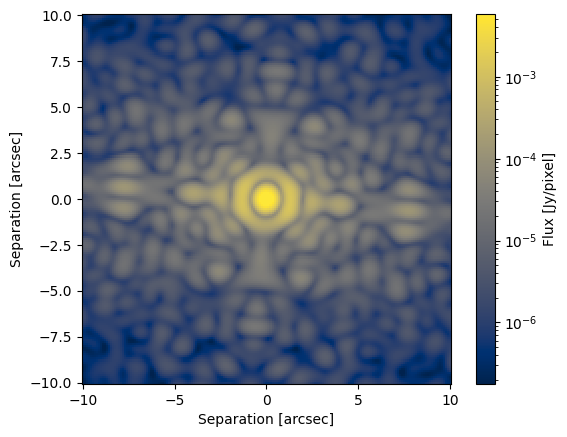

In [4]:
# 1. Let's take the first PSF component
kernel = mxgrid.components[0]
# remove the bottom left corner of this kernel to make it more interesting
#kernel[:len(kernel) // 2, :len(kernel) // 2] = 0
from xrdi_toolkit import *
plot_image2d(kernel)

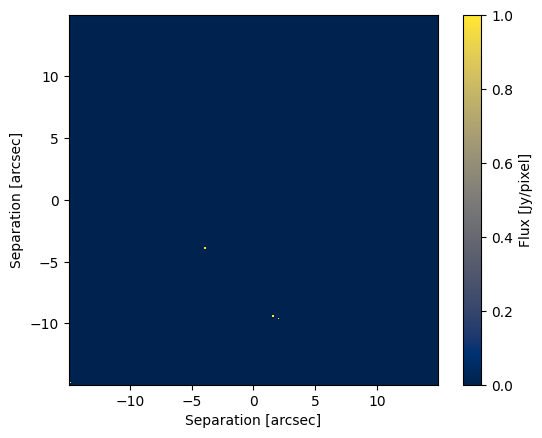

In [5]:
# build some diracs
dirac0 = mxgrid.dirac(i=1, j=1)
dirac1 = mxgrid.dirac(i=100, j=100)
dirac2 = mxgrid.dirac(i=150, j=50)
dirac3 = mxgrid.dirac(i=154, j=48)
dirac = dirac0 + dirac1 + dirac2 + dirac3
dirac = dirac

plot_image2d(dirac, qmax=1, qmin=0)

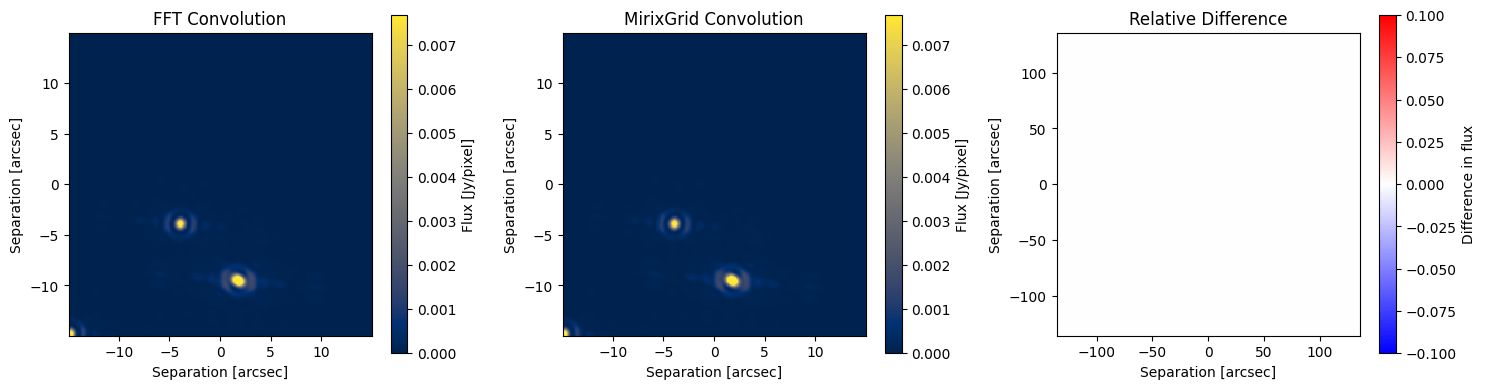

In [6]:
# let's convole!
from scipy.signal import fftconvolve
import numpy as np
image = fftconvolve(dirac * mxgrid.coefficients[:, :, 0], kernel, mode="same")
image_mxgrid = mxgrid.forward(dirac)
difference = (image - image_mxgrid) / np.max(image_mxgrid)

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("FFT Convolution")
plot_image2d(image)
plt.subplot(1, 3, 2)
plt.title("MirixGrid Convolution")
plot_image2d(image_mxgrid)
plt.subplot(1, 3, 3)
plt.title("Relative Difference")
plot_image2d(difference, qmax=1, qmin=0, colormap="bwr", colorbar_label="Difference in flux", pixel_scale_arcsec=1)
plt.tight_layout()
plt.show()

Let's try to get that back myself!

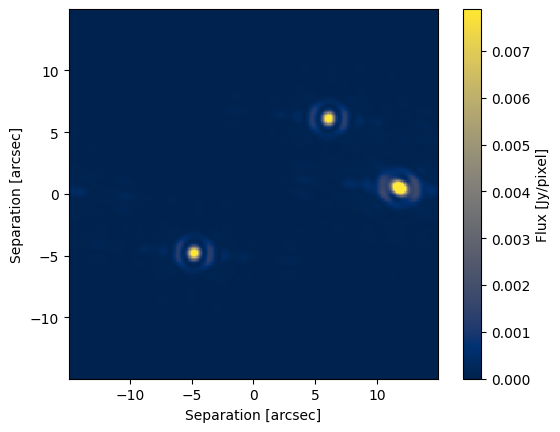

[~] Convolving with FFT

 (0.079s)
[~] Convolving with FFT (mxgrid) (0.043s)


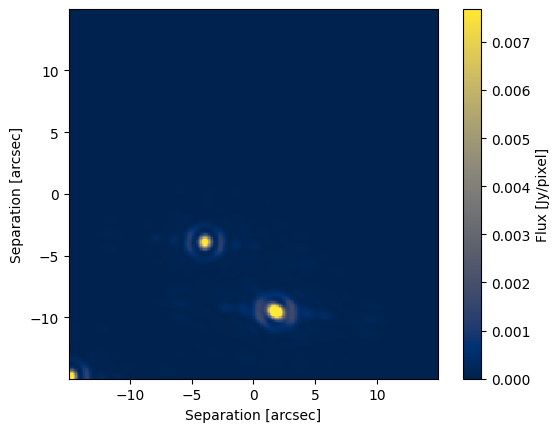

In [7]:
from scipy.fft import fft2, ifft2, fftshift, next_fast_len
import numpy as np
import matplotlib.pyplot as plt

def fftconvole_test1(image, kernal):
    F_image = fft2(image)
    F_kernal = fft2(kernal, s=image.shape)
    F_convolved = F_image * F_kernal
    convolved = ifft2(F_convolved)
    return np.real(convolved)


test_output = fftconvole_test1(dirac, kernel)
plot_image2d(test_output)
plt.show()

def _centered(arr: np.ndarray, newshape: tuple[int, int]) -> np.ndarray:
    """
    Return the centered portion of arr with shape newshape.
    Matches scipy.signal._centered.
    """
    currshape = np.array(arr.shape)
    newshape = np.array(newshape)
    startind = (currshape - newshape) // 2
    endind = startind + newshape
    return arr[startind[0]:endind[0], startind[1]:endind[1]]

def fftconvole_test2(image, kernal):    
    s1 = np.array(image.shape)
    s2 = np.array(kernal.shape)
    shape = tuple(s1 + s2 - 1)
    
    # pad to fft friendly size
    fshape = tuple(next_fast_len(s) for s in shape)
       
    
    sp1 = fft2(image, s=fshape)
    sp2 = fft2(kernal, s=fshape)
    ret = ifft2(sp1 * sp2, s=fshape)
    ret = ret[:shape[0], :shape[1]] # remove padding
    
    # crop to output shape
    ret = _centered(ret, s1)
    
    return np.real(ret)

with Task("Convolving with FFT"):
    for i in range(20):
        test_output2 = fftconvole_test2(dirac * mxgrid.coefficients[:, :, 0], kernel)
with Task("Convolving with FFT (mxgrid)"):
    with Message.mute():
        for i in range(20):
            test_output3 = mxgrid.forward(dirac)
        
plot_image2d(test_output2)
plt.show()
    

Relative difference: 9.058456133199502e-08


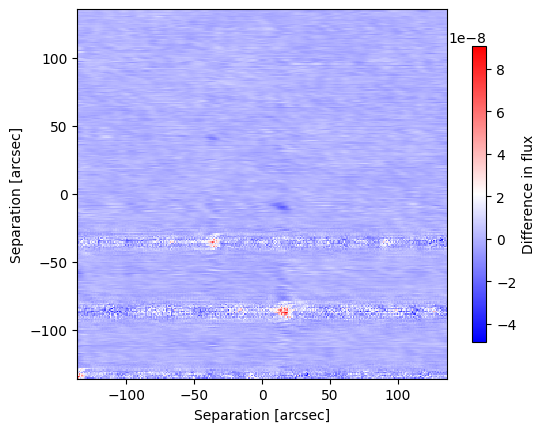

In [8]:
# compare the two outputs
difference = (image - test_output2) / np.max(image)
plot_image2d(
    difference,
    qmax=1,
    qmin=0,
    log_scale=False,
    colormap="bwr",
    colorbar_shrink=0.8,
    colorbar_label="Difference in flux",
    pixel_scale_arcsec=1,
)

print("Relative difference:", np.max(np.abs(difference)))

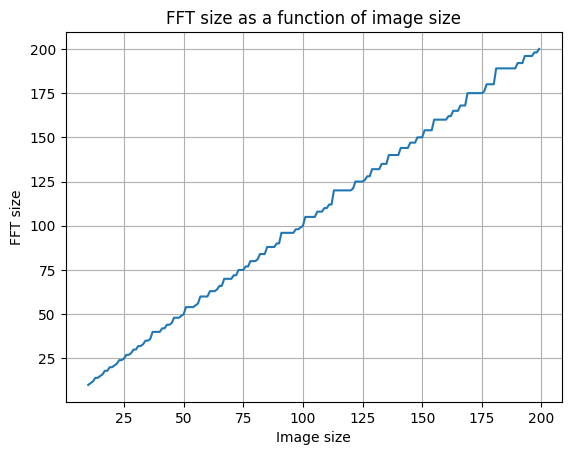

In [9]:
_image_shapes = np.arange(10, 200, 1)
fast_lengths = [next_fast_len(s) for s in _image_shapes]
plt.plot(_image_shapes, fast_lengths)
plt.xlabel("Image size")
plt.ylabel("FFT size")
plt.title("FFT size as a function of image size")
plt.grid()
plt.show()

In [11]:
# try mxgrid.forard_opt vs mxgrid.forward

mxgrid = MirixGrid(
    "src/mirix_grids/data/grid_filter-F1140C_nlambda-1_oversample-4_date-2023-09-04_psfshape-183_gridshape-272_psfoversample-2_pca_k-200.fits",
    pca_k=200
)

with Task("Running foward()"):
    image = mxgrid.forward(dirac)
with Task("Running forward_opt()"):
    image_opt = mxgrid.forward_opt(dirac)

[~] Loading grid (0.793s)
[i] Grid metadata:
 > filter:         F1140C
 > nlambda:        1
 > oversample:     4
 > date:           2023-09-04
 > psf_shape:      183
 > gridsize:       272
 > psf_oversample: 2
 > pca_k:          200
[i] Data shapes:
 > components:      (200, 183, 183)
 > coefficients:    (73984, 200)
 > singular_values: (200,)
 > xgrid:           (73984,)
 > ygrid:           (73984,)
[i] Data shapes after reshape:
 > components:     (200, 183, 183)
 > coefficients:   (272, 272, 200)
 > xgrid:          (272, 272)
 > ygrid:          (272, 272)
 > components_fft: (462, 462, 200)
[~] Running foward() (0.455s)
[~] Running forward_opt() (0.675s)


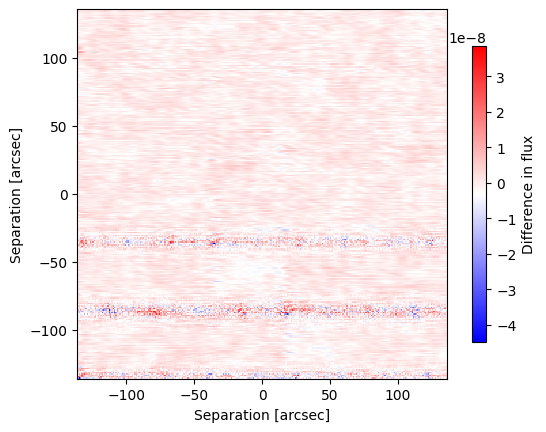

In [12]:
# comapre image and image_opt
difference = (image - image_opt) / np.max(image)
plot_image2d(
    difference,
    qmax=1,
    qmin=0,
    log_scale=False,
    colormap="bwr",
    colorbar_shrink=0.8,
    colorbar_label="Difference in flux",
    pixel_scale_arcsec=1,
)

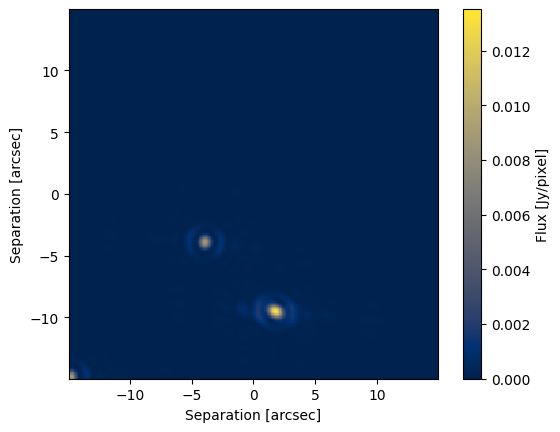

In [ ]:
plot_image2d(image, qmax=1, qmin=0)

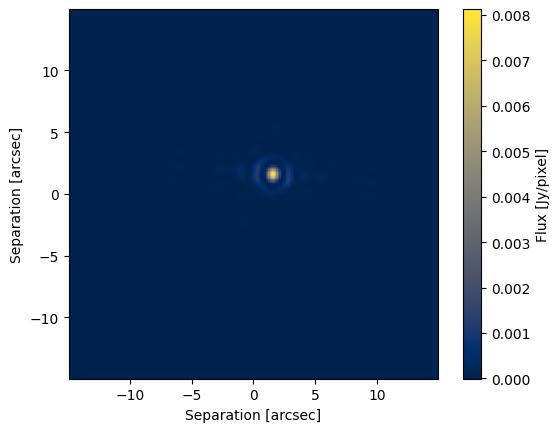

In [ ]:
dirac = mxgrid.dirac(i=150, j=150)
propagated = mxgrid.forward(dirac)
plot_image2d(propagated, qmax=1, qmin=0)